# Analyzing the results from our initial 3 models (SGD, MNB, and LDA)

Loading in our three models...

In [36]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [37]:
pipeline_mnb = joblib.load("models/mnb_baseline.pkl")
pipeline_lda = joblib.load("models/lda_baseline.pkl")
pipeline_sgd = joblib.load("models/sgd_baseline.pkl")

In [38]:
df = pd.read_csv("data/merged_data.csv", index_col="date", parse_dates=True)
df.sort_index(inplace=True)

X = df[["summary", "pct_change", "volume"]]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

Collecting results...

In [39]:
results = {}

for name, pipeline in {
    "MNB": pipeline_mnb,
    "LDA": pipeline_lda,
    "SGD": pipeline_sgd,
}.items():
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    results[name] = {
        "accuracy": acc,
        "report": report,
        "confusion_matrix": cm,
    }

for name, res in results.items():
    print(f"{name} Accuracy: {res['accuracy']:.3f}")
    print(f"{name} Classification Report:\n", pd.DataFrame(res["report"]))
    print(f"{name} Confusion Matrix:\n", res["confusion_matrix"])

MNB Accuracy: 0.546
MNB Classification Report:
                  0.0        1.0  accuracy   macro avg  weighted avg
precision   0.483871   0.565657  0.546154    0.524764      0.529168
recall      0.258621   0.777778  0.546154    0.518199      0.546154
f1-score    0.337079   0.654971  0.546154    0.496025      0.513142
support    58.000000  72.000000  0.546154  130.000000    130.000000
MNB Confusion Matrix:
 [[15 43]
 [16 56]]
LDA Accuracy: 0.654
LDA Classification Report:
                  0.0        1.0  accuracy   macro avg  weighted avg
precision   0.644444   0.658824  0.653846    0.651634      0.652408
recall      0.500000   0.777778  0.653846    0.638889      0.653846
f1-score    0.563107   0.713376  0.653846    0.638241      0.646333
support    58.000000  72.000000  0.653846  130.000000    130.000000
LDA Confusion Matrix:
 [[29 29]
 [16 56]]
SGD Accuracy: 0.531
SGD Classification Report:
                  0.0        1.0  accuracy   macro avg  weighted avg
precision   0.483516   0

<Axes: >

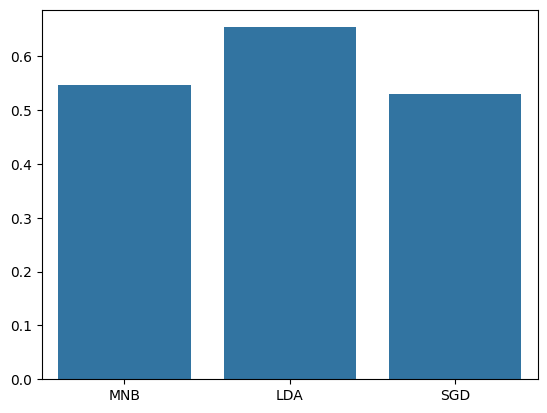

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

model_names = list(results.keys())
accuracies = [results[name]["accuracy"] for name in model_names]
sns.barplot(x=model_names, y=accuracies)

Our analysis identifies Linear Discriminant Analysis (LDA) as the superior model, achieving a remarkable 65.4% accuracy compared to the mid-50s for the others. While the Naive Bayes model acted like an "optimist" (predicting "Up" almost exclusively) and the SGD classifier acted like a "pessimist" (over-predicting crashes), LDA succeeded by finding a healthy balance between the two.

It was the only model capable of capturing the market's upside (78% of rallies) while still providing decent protection against the downside (detecting 50% of drops), proving that the relationship between financial news and stock movement is best modeled by finding a clean linear boundary between the classes.

#### However

This was with a relatively small dataset. We hadn't realized how small our dataset was until we filtered it down, because once we group all of our data by date that meant we would only have at max around 250 datapoints per year, since we lose weekends and holidays. 

Let's get more data and see how well our initial models do, then we can try to improve them further.